# **DECISION TREES IMPLEMENTATION**

In [ ]:
#Importing libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix

In [ ]:
#Load dataset
iris = load_iris()
X=iris.data
y=iris.target

df=pd.DataFrame(X, columns= iris.feature_names)
df["Species"] = y
print(df.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   Species  
0        0  
1        0  
2        0  
3        0  
4        0  


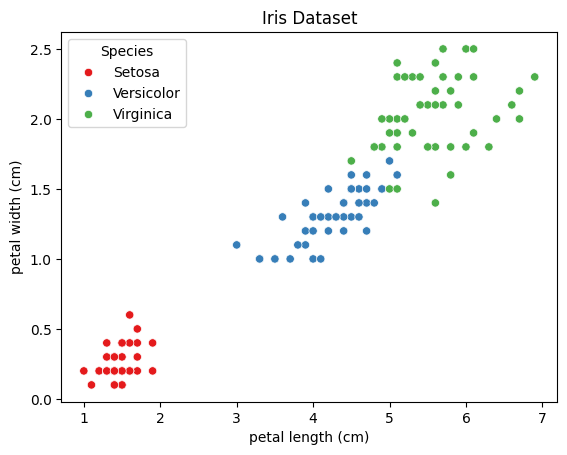

In [ ]:
#Visualising the data
df['Species']=df['Species'].map({
    0:"Setosa",
    1:"Versicolor",
    2:"Virginica"
})

sns.scatterplot(data=df,x="petal length (cm)", y="petal width (cm)", hue="Species", palette="Set1")
plt.title("Iris Dataset")
plt.show()

In [ ]:
#Understand the datset
print(df.shape)
df.info()
df.describe()

(150, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   Species            150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [ ]:
#Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,y,
    test_size=0.2,
    random_state=42
)

In [ ]:
#Creating the model
model=DecisionTreeClassifier(
    criterion="entropy",
    random_state=42
)

In [ ]:
#Training the model
model.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', random_state=42)

In [ ]:
#Make predictions
y_pred=model.predict(X_test)

In [ ]:
#Accuracy
accuracy=accuracy_score(y_test,y_pred)
print("Accuracy: ", accuracy)

Accuracy:  1.0


In [ ]:
#Confusion Matrix
cm=confusion_matrix(y_test,y_pred)
print(cm)

[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


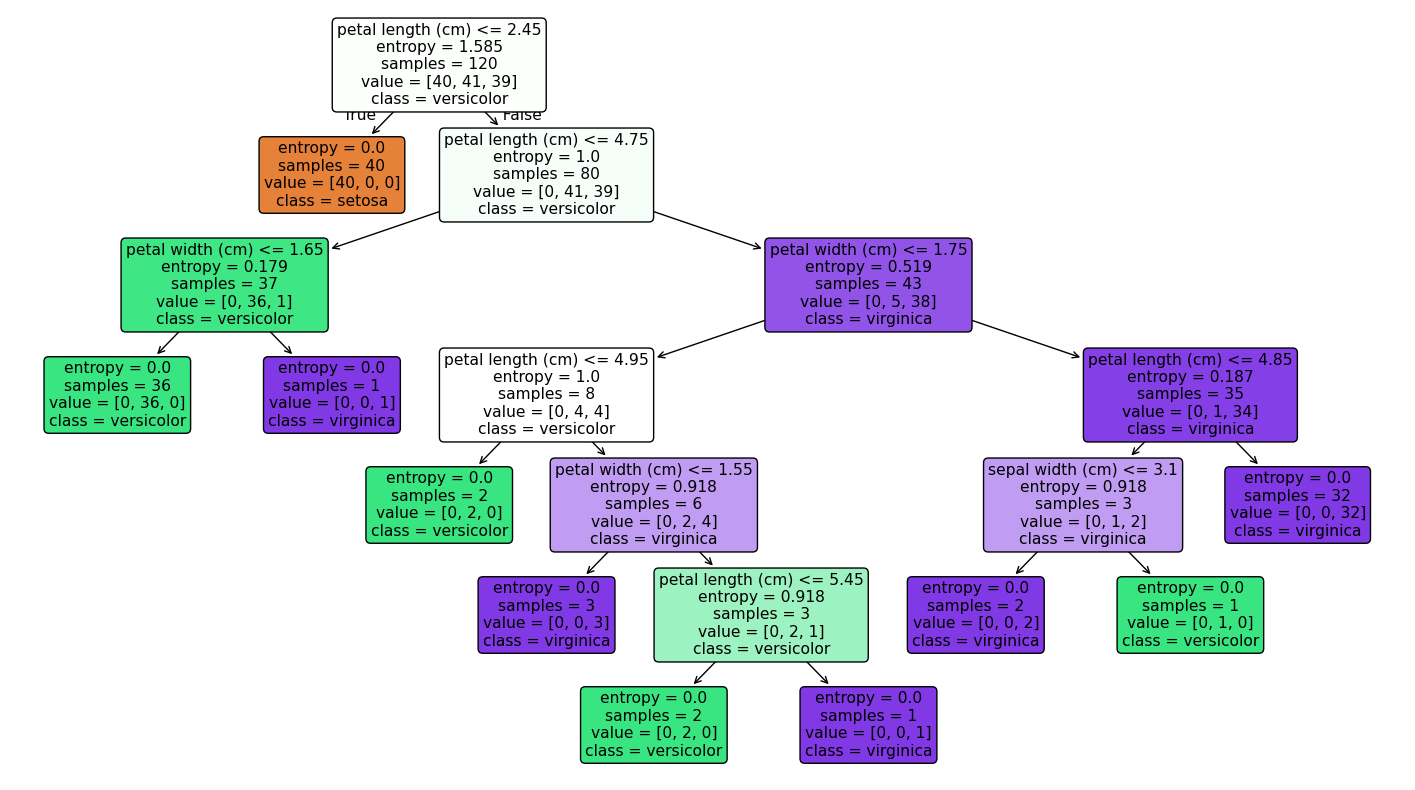

In [ ]:
#Decision Tree

plt.figure(figsize=(18,10))
plot_tree(
    model,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True,
    rounded=True
)
plt.show()

In [ ]:
#Feature Importance

importance= pd.DataFrame({
    "Feature": iris.feature_names,
    "Importance": model.feature_importances_
})
print(importance.sort_values(by="Importance", ascending=False))

             Feature  Importance
2  petal length (cm)    0.895406
3   petal width (cm)    0.090107
1   sepal width (cm)    0.014487
0  sepal length (cm)    0.000000


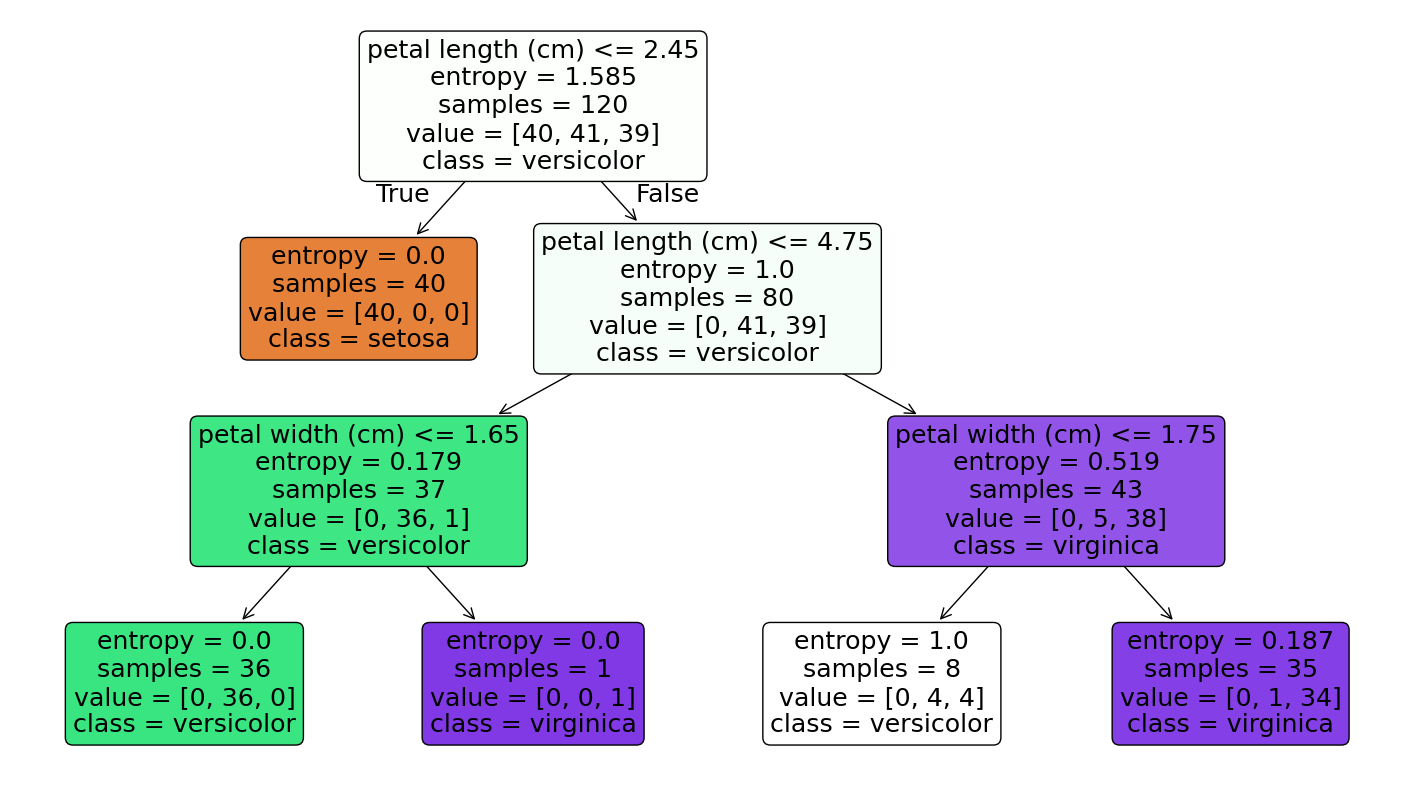

In [ ]:
#Pruning
model_pruned = DecisionTreeClassifier(
    criterion="entropy",
    random_state=42,
    ccp_alpha=0.05
)
model_pruned.fit(X_train,y_train)
plt.figure(figsize=(18,10))
plot_tree(
    model_pruned,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True,
    rounded=True
)
plt.show()


In [ ]:
#Accuracy after prunimg
y_pred_pruned= model_pruned.predict(X_test)
accuracy_pruned= accuracy_score(y_test,y_pred_pruned)
print("Accuracy after pruning: ", accuracy_pruned)

Accuracy after pruning:  1.0
